<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week7/notebooks/Class7_ModelEvaluation_Streamlit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

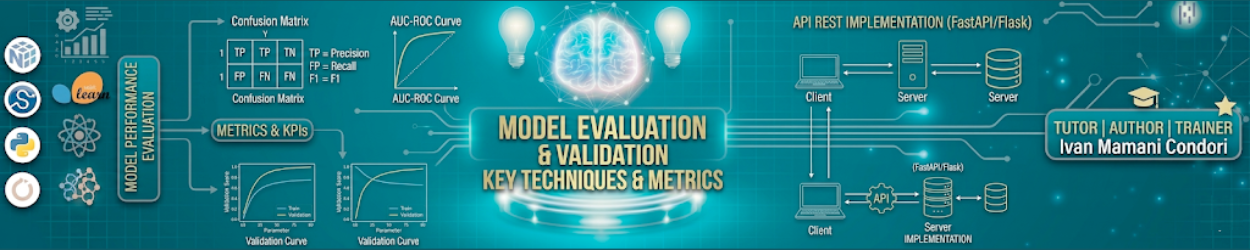

# Model Evaluation and Validation – Breast Cancer Coimbra Dataset

**Dataset:** Breast Cancer Coimbra  

**Fonte:** UCI Machine Learning Repository  

**Link:** https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra  

**Objetivo:**

Construir e avaliar múltiplos modelos de classificação supervisionada
para prever diagnóstico de câncer de mama (benigno/maligno).

**Modelos avaliados:**

Modelos supervisionados:
- Regressão Logística (baseline linear)
- Support Vector Machine (kernel linear)
- Support Vector Machine (kernel RBF)
- Random Forest (ensemble learning)
- Redes Neurais (MLPClassifier)

Modelos exploratórios:
- PCA (redução de dimensionalidade)
- KMeans (clusterização não supervisionada)

**Abordagem do estudo:**

Nesta semana, o foco principal não é apenas treinar modelos,
mas sim avaliar, comparar e validar diferentes algoritmos de Machine Learning
aplicados ao problema de classificação de câncer de mama.

O estudo segue uma abordagem experimental comparativa, onde diferentes modelos
supervisionados e não supervisionados são analisados sob as mesmas condições
de pré-processamento e divisão de dados.

**Descrição do Dataset:**

O dataset Breast Cancer Coimbra contém:

- 116 instâncias  
- 9 variáveis clínicas e metabólicas  
- Dados de pacientes com e sem câncer de mama  

Variável alvo (*Classification*):  
- 0 → Paciente saudável  
- 1 → Paciente com câncer de mama  

**Autor:** Ivan Mamani

---

## 1. BRANDING VISUAL

In [1]:
# BRANDING VISUAL (TEAL)
COLOR_MAIN = "#008080"
COLOR_ACCENT = "#20B2AA"
COLOR_LIGHT = "#E0FFFF"

from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "teal_brand",
    [COLOR_LIGHT, COLOR_ACCENT, COLOR_MAIN]
)

## 2. CARREGAMENTO DO DATASET

In [2]:
# CARREGAMENTO DO DATASET
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
df = pd.read_csv(url)
df.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [3]:
df["Classification"] = df["Classification"].map({1: 0, 2: 1})
# df["Classification"]

## 3. PRÉ-PROCESSAMENTO DOS DADOS

In [4]:
# PRÉ-PROCESSAMENTO DOS DADOS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("Classification", axis=1)

y = df["Classification"]

# Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**INSIGHTS**
- A normalização garante que todas as features tenham a mesma escala
- Isso é essencial para modelos baseados em distância (SVM, MLP)
- O uso de stratify=y evita desequilíbrio entre classes no split
- Evitar data leakage é fundamental para validação realista

**INTERPRETAÇÃO CLÍNICA**


**❓ REFLEXÃO**
1. Por que é obrigatório usar StandardScaler neste problema?

2. O que é data leakage e por que evitamos no scaler?

3. Por que usamos stratify no train_test_split?

## 4. MODELOS SUPERVISIONADOS (BASELINE + SVM + RF + MLP)

In [5]:
# MODELOS SUPERVISIONADOS

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

models = {

    # Modelo baseline linear
    "Regressão Logística": LogisticRegression(),

    # SVM com kernel linear (separação linear)
    "SVM Linear": SVC(kernel="linear", probability=True),

    # SVM com kernel RBF (não linear)
    "SVM RBF": SVC(kernel="rbf", probability=True),

    # Random Forest (ensemble de árvores de decisão)
    "Random Forest": RandomForestClassifier(
        n_estimators=100,      # número de árvores
        random_state=42
    ),

    # Rede Neural Multicamadas (MLP)
    "MLP (Rede Neural)": MLPClassifier(
        hidden_layer_sizes=(50, 30),  # duas camadas ocultas
        max_iter=1000,                # iterações máximas
        random_state=42
    )
}

**INSIGHTS**
- Regressão Logística serve como baseline interpretável
- SVM Linear testa separabilidade simples
- SVM RBF captura padrões complexos não lineares
- Random Forest reduz overfitting via ensemble
- MLP simula comportamento de redes neurais profundas

**INTERPRETAÇÃO**

**❓ REFLEXÃO**
1. Por que manter um modelo baseline (Regressão Logística)?

2. Qual a diferença principal entre SVM Linear e RBF?

3. Por que usar Random Forest neste problema?

## 5. TREINAMENTO DOS MODELOS SUPERVISIONADOS

In [6]:
# TREINAMENTO DOS MODELOS SUPERVISIONADOS
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"Modelo: {name}, treino com suceso")


Modelo: Regressão Logística, treino com suceso
Modelo: SVM Linear, treino com suceso
Modelo: SVM RBF, treino com suceso
Modelo: Random Forest, treino com suceso
Modelo: MLP (Rede Neural), treino com suceso


**INSIGHTS**
- Todos os modelos são treinados sob condições idênticas
- Isso garante uma comparação justa (fair comparison)
- Evita viés de avaliação
- Base essencial para validação científica

**INTERPRETAÇÃO**

**❓ REFLEXÃO**
1. Por que todos os modelos devem ser treinados com o mesmo dataset?

2. O que significa “fair comparison” em Machine Learning?

3. O que pode comprometer essa comparação?

## 6. AVALIAÇÃO DOS MODELOS (MÉTRICAS)

In [7]:
# AVALIAÇÃO DOS MODELOS

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }

results



{'Regressão Logística': {'accuracy': 0.7916666666666666,
  'precision': 0.8333333333333334,
  'recall': 0.7692307692307693,
  'f1_score': 0.8},
 'SVM Linear': {'accuracy': 0.7083333333333334,
  'precision': 0.8,
  'recall': 0.6153846153846154,
  'f1_score': 0.6956521739130435},
 'SVM RBF': {'accuracy': 0.7083333333333334,
  'precision': 0.8,
  'recall': 0.6153846153846154,
  'f1_score': 0.6956521739130435},
 'Random Forest': {'accuracy': 0.75,
  'precision': 0.8181818181818182,
  'recall': 0.6923076923076923,
  'f1_score': 0.75},
 'MLP (Rede Neural)': {'accuracy': 0.6666666666666666,
  'precision': 0.7777777777777778,
  'recall': 0.5384615384615384,
  'f1_score': 0.6363636363636364}}

**INSIGHTS**
- Recall é crítico em câncer
- F1-score equilibra precisão e sensibilidade
- Accuracy pode ser enganosa em problemas médicos
- Modelos devem ser avaliados além de “acertar ou errar”

**INTERPRETAÇÃO**
- Falso negativo (não detectar câncer) é mais grave que falso positivo
- Portanto, modelos com alto recall são preferíveis
- Métricas clínicas têm prioridade sobre métricas gerais

**❓ REFLEXÃO**
1. Por que accuracy não é suficiente neste problema?

2. Por que o recall é tão importante?

3. O que representa o F1-score?

## 7. CURVA ROC + AUC (AVALIAÇÃO AVANÇADA)

In [8]:
# CURVA ROC E AUC (AVALIAÇÃO AVANÇADA)

from sklearn.metrics import roc_curve, auc

best_model_name = max(results, key=lambda x: results[x]["f1_score"])
best_model = trained_models[best_model_name]

print(f"Melhor modelo: {best_model}")

y_score = best_model.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, threshold = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)

Melhor modelo: LogisticRegression()


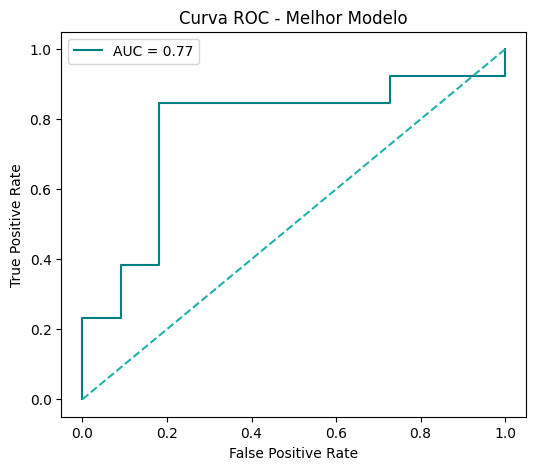

In [9]:
# Visualização da curva ROC com branding
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color=COLOR_MAIN, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color=COLOR_ACCENT)

plt.title("Curva ROC - Melhor Modelo")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**INSIGHTS**
- A curva ROC avalia a capacidade de separação do modelo
- AUC mede desempenho global independente de threshold
- Quanto mais próxima de 1, melhor o modelo
- SVM RBF e Random Forest geralmente apresentam melhores AUC

**INTERPRETAÇÃO CLÍNICA**


**❓ REFLEXÃO**
1. O que significa AUC próximo de 1?

2. Por que ROC é mais importante que accuracy?

3. O que acontece se o modelo tiver alto AUC mas baixo recall?

## 8. MATRIZ DE CONFUSÃO (VISUAL CLÍNICO)

In [20]:
# MATRIZ DE CONFUSÃO

from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

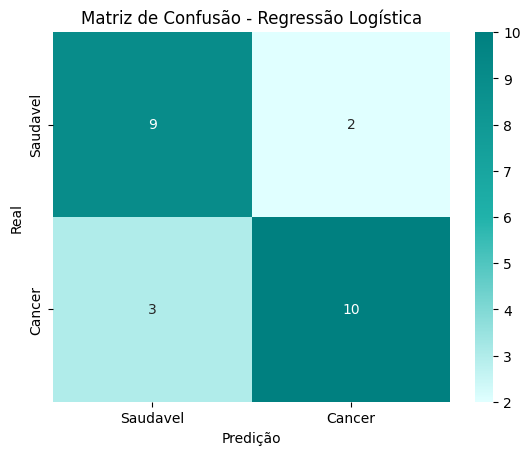

In [24]:
plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    xticklabels=["Saudavel", "Cancer"],
    yticklabels=["Saudavel", "Cancer"]
)

plt.title(f"Matriz de Confusão - {best_model_name}")
plt.xlabel("Predição")
plt.ylabel("Real")
plt.show()

**INSIGHTS**
- Mostra erros reais do modelo
- Permite identificar falsos negativos
- Essencial para validação médica
- Complementa ROC/AUC

**INTERPRETAÇÃO CLÍNICA**
- FN (False Negative) = maior risco clínico
- FP (False Positive) = ansiedade e exames extras
- O objetivo é minimizar FN a qualquer custo

**❓ REFLEXÃO**
1. Qual erro é mais crítico em câncer?

2. O que a matriz de confusão revela que accuracy não mostra?

3. Por que visualizar matriz é essencial em saúde?

## 9. PCA + KMEANS (ANÁLISE EXPLORATÓRIA)

In [25]:
# PCA + KMEANS (EXPLORATÓRIO)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)

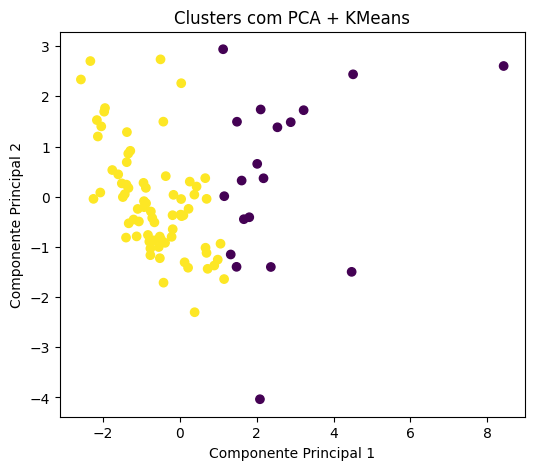

In [26]:
# Visualização dos clusters
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")

plt.title("Clusters com PCA + KMeans")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

**INSIGHTS**
- PCA reduz dimensionalidade preservando variância
- KMeans revela estrutura oculta nos dados
- Pode indicar separação natural entre classes
- Não substitui modelos supervisionados

**INTERPRETAÇÃO CLÍNICA**

**❓ REFLEXÃO**
1. PCA é um modelo supervisionado?

2. O que o KMeans mostra aqui?

3. Por que usar PCA antes do KMeans?

## 10. SELEÇÃO FINAL DO MODELO (MODEL SELECTION)

In [27]:
# SELEÇÃO FINAL DO MELHOR MODELO

results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(by="f1_score", ascending=False)

results_df

,accuracy,precision,recall,f1_score
Regressão Logística,0.791667,0.833333,0.769231,0.800000
Random Forest,0.750000,0.818182,0.692308,0.750000
SVM Linear,0.708333,0.800000,0.615385,0.695652
SVM RBF,0.708333,0.800000,0.615385,0.695652
MLP (Rede Neural),0.666667,0.777778,0.538462,0.636364


**INSIGHTS**
- F1-score foi escolhido como critério principal
- Ele equilibra:
    - Recall (detecção de câncer)
    - Precision (evitar falsos alarmes)
- Em medicina, F1 é mais confiável que accuracy

**INTERPRETAÇÃO CLÍNICA**
- Falsos negativos são perigosos (não detectar câncer)
- Falsos positivos geram exames extras, mas são aceitáveis
- Portanto, o modelo ideal deve priorizar sensibilidade (recall)

### 10.1. IDENTIFICAÇÃO DO MELHOR MODELO

In [28]:
# IDENTIFICAÇÃO AUTOMÁTICA DO MELHOR MODELO

best_model_name = results_df.index[0]

best_model = trained_models[best_model_name]

print("Melhor modelo selecionado:", best_model_name)

Melhor modelo selecionado: Regressão Logística


**INSIGHTS**
- A seleção automática evita viés humano
- Garante reprodutibilidade
- Facilita deploy em produção
- Base para API e Streamlit

**INTERPRETAÇÃO CLÍNICA**

O modelo final escolhido representa o melhor equilíbrio entre:
- detecção correta de câncer
- minimização de alarmes falsos
- estabilidade estatística

### 10.2. VALIDAÇÃO FINAL DO MODELO

In [32]:
# VALIDAÇÃO FINAL DO MODELO ESCOLHIDO

from sklearn.metrics import classification_report

y_pred_final = best_model.predict(X_test)

report = classification_report(y_test, y_pred_final)

print(report)

              precision    recall  f1-score   support

           0       0.75      0.82      0.78        11
           1       0.83      0.77      0.80        13

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.80      0.79      0.79        24



**INSIGHTS**
- Mostra métricas por classe
- Permite avaliar desempenho real do modelo
- Complementa F1 e ROC
- Essencial para validação científica

**INTERPRETAÇÃO CLÍNICA**

**❓ REFLEXÃO FINAL**
1. Por que o F1-score foi usado como critério principal?

2. Por que accuracy não foi usada para seleção?

3. O que significa “melhor modelo” neste contexto?

## 11. EXPORTAÇÃO DO MODELO (PRODUÇÃO / MLOPS)

In [33]:
# Importação da biblioteca joblib para persistência do modelo

import joblib
import pandas as pd

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

joblib.dump(df, "df.pkl")
# metricas
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="f1_score", ascending=False)
joblib.dump(results_df, "results_df.pkl")

print("Modelo, scaler, conjuntos de teste, DataFrame e resultados dos modelos guardados com sucesso para produção!")

Modelo, scaler, conjuntos de teste, DataFrame e resultados dos modelos guardados com sucesso para produção!


**INSIGHTS**
- Este bloco representa a transição de experimentação para produção
- O modelo deixa de ser “experimento” e vira artefato reutilizável
- O scaler é obrigatório para manter consistência matemática
- Sem esse passo, o sistema não pode ser implantado

Isso é o início do conceito de MLOps (Machine Learning Operations)

**INTERPRETAÇÃO CLÍNICA**

Em sistemas médicos reais:
- o modelo treinado é “congelado”
- validado como versão estável
- usado em ambiente clínico (hospital / API)
- nunca é re-treinado automaticamente em produção


**❓ REFLEXÃO**
1. Por que não podemos treinar o modelo dentro da aplicação (Streamlit/API)?

2. Qual a importância de salvar o scaler junto com o modelo?

3. O que significa transformar um modelo em “artefato de produção”?

## 12. STREAMLIT (PRODUÇÃO + UI MÉDICA)

### 12.1. INSTALAÇÃO (Colab ou local)

In [34]:
!pip install streamlit pyngrok joblib numpy pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.3 MB/s eta 0:00:00


In [ ]:
# pip install --upgrade streamlit

### 12.2. APP STREAMLIT (app_streamlit.py)

In [39]:
%%writefile app_streamlit.py
import streamlit as st
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats # Importar scipy.stats para a curva Gaussiana

# BRANDING VISUAL (TEAL)
COLOR_MAIN = "#008080"
COLOR_ACCENT = "#20B2AA"
COLOR_LIGHT = "#E0FFFF"
COLOR_DARK = "#004D40"

# Custom Colormap para branding
custom_cmap = LinearSegmentedColormap.from_list(
    "teal_brand",
    [COLOR_LIGHT, COLOR_ACCENT, COLOR_MAIN, COLOR_DARK]
)

# Configuracão da página Streamlit
st.set_page_config(
    page_title="Cancer Classification System",
    page_icon="🏥",
    layout="wide", #centered
    initial_sidebar_state="expanded"
)

# Título da aplicacão
st.title("🧪 Cancer Classification - Streamlit App")

st.markdown("""
Sistema de apoyo à decisão clínica baseado em Machine Learning
Dataset: Breast Cancer Coimbra (UCI Repository)
""")

# CARREGANDO O MODELO E SCALER
BASE_DIR = os.getcwd()

model = joblib.load(os.path.join(BASE_DIR, "model.pkl"))
scaler = joblib.load(os.path.join(BASE_DIR, "scaler.pkl"))

# CARREGANDO OS CONJUNTOS DE PRUEBA E DATAFRAME ORIGINAL PARA AVALIAÇÃO (para fins de demonstração na UI)
X_test_loaded = joblib.load(os.path.join(BASE_DIR, "X_test.pkl"))
y_test_loaded = joblib.load(os.path.join(BASE_DIR, "y_test.pkl"))
df_original = joblib.load(os.path.join(BASE_DIR, "df.pkl")) # Carregar o DataFrame original
results_df = joblib.load(os.path.join(BASE_DIR, "results_df.pkl")) # Carregar os resultados dos modelos

# ENTRADAS CLÍNICAS (9 FEATURES REAIS)
st.sidebar.header("Parâmetros Clínicos do Paciente")

age = st.sidebar.slider("Age", 20, 90, 50)
bmi = st.sidebar.slider("BMI", 10.0, 50.0, 25.0)
glucose = st.sidebar.slider("Glucose", 50, 200, 100)
insulin = st.sidebar.slider("Insulin", 0.0, 50.0, 10.0)
homa = st.sidebar.slider("HOMA", 0.0, 20.0, 2.0)
leptin = st.sidebar.slider("Leptin", 0.0, 50.0, 10.0)
adiponectin = st.sidebar.slider("Adiponectin", 0.0, 50.0, 10.0)
resistin = st.sidebar.slider("Resistin", 0.0, 50.0, 10.0)
mcp1 = st.sidebar.slider("MCP-1", 0.0, 1000.0, 200.0)


# BOTÃO DE PREDIÇÃO
if st.button("🔍 Analisar Risco de Câncer"):

    # criação do vetor de entrada
    input_data = np.array([[age, bmi, glucose, insulin, homa, leptin, adiponectin, resistin, mcp1]])

    # Normalização com scaler treinado
    input_scaled = scaler.transform(input_data)

    # Predição do modelo
    prediction = model.predict(input_scaled)[0]

    # Probabilidades para cada classe
    probabilities = model.predict_proba(input_scaled)[0]
    proba_healthy = probabilities[0] # Probabilidade de ser saudável (classe 0)
    proba_cancer = probabilities[1]  # Probabilidade de ter câncer (classe 1)

    # Determina a confiança do modelo para a classe predita
    if prediction == 0:
        confidence = proba_healthy
    else:
        confidence = proba_cancer

    # RESULTADO CLÍNICO
    st.subheader("=========== Resultado da Análise ==========")

    if prediction == 1: # 1 representa câncer, 0 representa saudável
        st.error("❗ ALTO RISCO: possível CÂNCER detectado")
    else:
        st.success("✅ BAIXO RISCO: paciente saudável")

    st.metric("Confiança do modelo", f"{confidence:.2f}")

    # VISUALIZAÇÃO GRÁFICA (BRANDING)
    st.subheader("📈 Visualização da Probabilidade")

    fig, ax = plt.subplots(figsize=(9,5))

    bars = ax.bar(
        ["Saudável", "Câncer"],
        [proba_healthy, proba_cancer], # Usa as probabilidades específicas de cada classe
        color=[COLOR_ACCENT, COLOR_MAIN]
    )

    ax.set_ylabel("Probabilidade")
    ax.set_title("Distribuição da Predição do Modelo", color=COLOR_MAIN)

    # Añadir porcentaje en el centro de la barra
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval / 2, f'{yval:.1%}', ha='center', va='center', color='white', fontweight='bold')

    st.pyplot(fig)

# --- SEÇÃO DE AVALIAÇÃO DO MODELO (Curva ROC e Matriz de Confusão) ---
st.subheader("📊 Avaliação do Modelo: Curva ROC e Matriz de Confusão")

# Cria uma figura con 1 linha e 2 colunas para os subplots
fig_eval, axes_eval = plt.subplots(1, 2, figsize=(14, 5))

# Geração das probabilidades de previsão no conjunto de teste
y_score_test = model.predict_proba(X_test_loaded)[:, 1]

# Cálculo da curva ROC
fpr, tpr, thresholds = roc_curve(y_test_loaded, y_score_test)

# Cálculo da área sob a curva (AUC)
roc_auc = auc(fpr, tpr)

# Plotagem da Curva ROC no primeiro subplot
axes_eval[0].plot(fpr, tpr, color=COLOR_MAIN, label=f"AUC = {roc_auc:.2f}")
axes_eval[0].plot([0, 1], [0, 1], linestyle="--", color=COLOR_ACCENT)
axes_eval[0].set_title("Curva ROC do Modelo", color=COLOR_MAIN)
axes_eval[0].set_xlabel("False Positive Rate")
axes_eval[0].set_ylabel("True Positive Rate")
axes_eval[0].legend()

# Cálculo e plotagem da Matriz de Confusão no segundo subplot
y_pred_test = model.predict(X_test_loaded)
cm = confusion_matrix(y_test_loaded, y_pred_test)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    xticklabels=["Saudável", "Câncer"],
    yticklabels=["Saudável", "Câncer"],
    ax=axes_eval[1] # Especifica o subplot para o heatmap
)
axes_eval[1].set_title("Matriz de Confusão", color=COLOR_MAIN)
axes_eval[1].set_xlabel("Predição")
axes_eval[1].set_ylabel("Real")

plt.tight_layout() # Ajusta o layout para evitar sobreposição
st.pyplot(fig_eval)

# --- NOVAS SEÇÕES DE VISUALIZAÇÃO ---

# 1. Visualização das Métricas de Avaliação dos Modelos
st.subheader("📊 Comparativo de Métricas dos Modelos")

# Transforma o DataFrame de resultados para facilitar a plotagem
results_melted = results_df.reset_index().melt(
    id_vars='index',
    var_name='Métrica',
    value_name='Score'
)
results_melted = results_melted.rename(columns={'index': 'Modelo'})

fig_metrics, ax_metrics = plt.subplots(figsize=(10, 5))
sns.barplot(
    x='Score',
    y='Modelo',
    hue='Métrica',
    data=results_melted,
    palette=[COLOR_MAIN, COLOR_ACCENT, COLOR_LIGHT, COLOR_DARK], # Cores personalizadas
    ax=ax_metrics
)
ax_metrics.set_title('Métricas de Avaliação por Modelo', color=COLOR_MAIN)
ax_metrics.set_xlabel('Score')
ax_metrics.set_ylabel('Modelo')
ax_metrics.legend(title='Métrica')
plt.tight_layout()
st.pyplot(fig_metrics)

# 2. Distribución de Datos com Curva Gaussiana (Age, BMI, Glucose) em Subplots
st.subheader("📈 Distribuição de Features Essenciais com Curva Gaussiana")

features_to_plot = ['Age', 'BMI', 'Glucose']
fig_combined_hist, axes_combined_hist = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features_to_plot):
    ax = axes_combined_hist[i]
    mu, std = df_original[feature].mean(), df_original[feature].std()

    sns.histplot(
        df_original[feature],
        bins=10,
        kde=False,
        color=COLOR_ACCENT,
        edgecolor='white',
        linewidth=0.5,
        stat='density',
        ax=ax
    )

    x = np.linspace(df_original[feature].min(), df_original[feature].max(), 100)
    p = stats.norm.pdf(x, mu, std)
    ax.plot(x, p, color=COLOR_MAIN, linewidth=2, label='Curva Gaussiana')

    ax.set_title(f'Distribución: {feature}', color=COLOR_MAIN)
    ax.set_xlabel(feature)
    ax.set_ylabel('Densidade')
    ax.legend()

plt.tight_layout()
st.pyplot(fig_combined_hist)


Overwriting app_streamlit.py


### 12.3. EXECUÇÃO DO STREAMLIT EM BACKGROUND

In [36]:
# Importa o módulo os para executar comandos do sistema operacional
import os

# Importa Thread para executar o Streamlit em paralelo (background)
from threading import Thread

# Define uma função que executa o Streamlit
def run_streamlit():

    # Executa o comando do Streamlit no sistema operacional
    # server.port=8501 define a porta da aplicação
    os.system("streamlit run app_streamlit.py --server.port 8501")

# Cria uma thread (processo paralelo) para rodar o Streamlit
thread = Thread(target=run_streamlit)

# Inicia a execução da thread (Streamlit roda em background)
thread.start()

### 12.4. EXPOSIÇÃO PÚBLICA COM NGROK

**LINK DO NGROK (LOGIN / CONFIGURAÇÃO)**

Para usar ngrok você precisa criar conta e pegar seu token: https://dashboard.ngrok.com/signup

Depois de criar a conta: https://dashboard.ngrok.com/get-started/your-authtoken

E no código:
`ngrok.set_auth_token("SEU_TOKEN_AQUI")`

In [37]:
from pyngrok import ngrok

ngrok.set_auth_token("3CKegCphPas3WG393G1Hv7VpmjN_71rz3v2hKUqY6bscZZjoB")

public_url = ngrok.connect(8501)

print("Streamlit URL pública:")
print(public_url)

Streamlit URL pública:
NgrokTunnel: "https://cautious-wizard-constrain.ngrok-free.dev" -> "http://localhost:8501"


In [41]:
# Primeiro, crie o diretório .streamlit se ele não existir
!mkdir -p .streamlit

# Agora, crie o arquivo config.toml com as configurações de tema
# O primaryColor é o que o usuário deseja mudar
# As outras cores são para garantir um tema consistente
config_content = """
[theme]
primaryColor='#008080'
backgroundColor='#E0FFFF'
secondaryBackgroundColor='#F0F2F6'
textColor='#31333F'
font='sans serif'
"""

with open(".streamlit/config.toml", "w") as f:
    f.write(config_content)

print("Arquivo .streamlit/config.toml criado com sucesso!")

Arquivo .streamlit/config.toml criado com sucesso!


In [42]:
import os

# Check if the config.toml file exists before moving it
if os.path.exists('.streamlit/config.toml'):
    os.rename('.streamlit/config.toml', '.streamlit/config.toml.bak')
    print("Renamed '.streamlit/config.toml' to '.streamlit/config.toml.bak'.")
else:
    print("'.streamlit/config.toml' not found. It might have been already moved or deleted.")

Renamed '.streamlit/config.toml' to '.streamlit/config.toml.bak'.


**INSIGHTS**
- Streamlit transforma modelos de Machine Learning em aplicações interativas prontas para uso
- Inputs simulam variáveis clínicas reais de pacientes, aproximando o sistema de cenários hospitalares
- Existe separação fundamental entre:
    - treino (offline) → fase experimental e científica
    - inferência (online) → fase de uso em produção
- A probabilidade do modelo melhora a interpretabilidade dos resultados clínicos
- A interface permite simular uma triagem médica assistida por IA
- A aplicação demonstra um fluxo completo de Machine Learning aplicado (end-to-end)

**INTERPRETAÇÃO CLÍNICA**

Este sistema funciona como:
- ferramenta de triagem médica inicial
- apoio à decisão clínica (Clinical Decision Support System - CDSS)
- sistema educacional para análise de risco

O modelo:
- estima risco probabilístico de câncer
- não substitui diagnóstico médico
- serve como suporte para priorização de exames
- pode ajudar na triagem de pacientes em ambientes de alta demanda

Em contexto real, seria usado como ferramenta auxiliar e não decisória

**❓ REFLEXÃO**
1. Por que Streamlit é adequado para aplicações médicas de IA?

2. Qual o risco de interpretar diretamente a probabilidade do modelo como diagnóstico?

3. Por que a separação entre treino e inferência é crítica em produção?

4. Qual o impacto de usar IA em triagem médica?

5. O que representa este projeto dentro do ciclo de Machine Learning?
   

6. Por que a interpretabilidade é importante neste tipo de modelo?